# Premier exemple d'utilisation de l'algorithme Hierarchical Refinement (HiRef)


We experiment with the implementation of Hierachical Refinement based on the low-rank LRSinkhorn solver, proposed by [Halmos et al., 2025],  an algorithm to scalably compute a full-rank alignment between two equally-sized input datasets X and Y by solving a hierarchy of low-rank OT.sub-problems. 

___
* L’idée maîtresse de l’article est de construire pas‑à‑pas une bijection entre deux nuages de points en ne manipulant que des sous‑problèmes de transport de rang très faible (r = 2).

* À chaque échelle on découpe (co‑clusterise) les deux jeux de données de manière cohérente, puis on raffine ces blocs jusqu’à obtenir des singletons. 

* L’union des raffinements fournit alors un couplage full‑rank, donc déterministe.

## 1. Import of libraries

* The proposed approach to implement HiRef algorithm use the OTT - JAX library and it is low rank Sinkhorn algorithm

* We strongly recommend to use the **```0.5.0``` version** which is the latest stable version of ```OTT-JAX```

In [46]:
# hi_ref_demo.py
import jax
import jax.numpy as jnp

import matplotlib.pyplot as plt

from ott.geometry import pointcloud
from ott.problems.linear import linear_problem
from ott.solvers.linear.sinkhorn_lr import LRSinkhorn
from ott.tools import plot
from ott.initializers.linear.initializers_lr import KMeansInitializer

print(ott.__version__) # we strongly recommend to use the 0.5.0 version which is the latest stable version of OTT-JAX

0.5.0


## 2. Cretation of a LinearProblem of two point clouds

> * The point clouds needs to be same size to use HiReF implementation

In [7]:
# ---------- données jouet : 8 points 2D -------------------------------
def create_points(rng, n, d):
    rngs = jax.random.split(rng, 2)
    x = jax.random.normal(rngs[0], (n, d))
    y = jax.random.normal(rngs[1], (n, d))
    a = 1 / n # Hi ref utilise des distribution uniforme 
    b = a
    return x, y, a, b

In [13]:
rng = jax.random.key(0)
n, d = 8, 2
x, y, _, _ = create_points(rng, n=n, d=d)

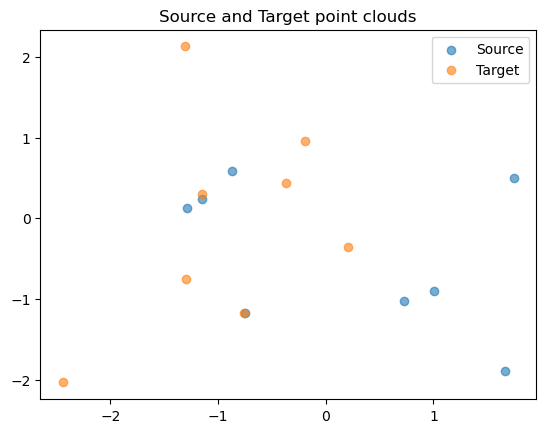

In [41]:
plt.scatter(x[:, 0], x[:, 1], label="Source", alpha=0.6)
plt.scatter(y[:, 0], y[:, 1], label="Target", alpha=0.6)
plt.legend()
plt.title("Source and Target point clouds")
plt.show()

In [42]:
# # ---------- sous‑routine low‑rank OT  ----------------------------------
# def low_rank_ot(geom,
#                 rank: int = 2):
#     """Résout un OT de rang=2 avec g uniforme, renvoie Q,R,g."""


#     # masses uniformes par défaut (a = b = 1/|bloc|)
#     ot_prob = linear_problem.LinearProblem(geom)

#     # choose and pass a KMeans initializer instance
#     initializer = KMeansInitializer(rank=rank,
#                                     min_iterations=50,
#                                     max_iterations=200)
#     solver = jax.jit(LRSinkhorn(rank=rank,
#                                 initializer=initializer))
#     ot_lr = solver(ot_prob)
    
#     # out.q, out.r, out.g contiennent Q,R,g (déjà normalisés)
#     return ot_lr

In [50]:
def low_rank_ot(x_block: jnp.ndarray,
                y_block: jnp.ndarray,
                rank: int = 2):
    """Résout un OT de rang `rank` avec g uniforme, renvoie Q, R, g."""
    # Geometry: Euclidean cost
    geom = pointcloud.PointCloud(x_block, y_block)

    # Définir le problème OT linéaire
    ot_prob = linear_problem.LinearProblem(geom)

    # Initialiseur k-means pour facteurs Q, R
    initializer = KMeansInitializer(rank=rank,
                                    min_iterations=50,
                                    max_iterations=200)

    # Solver low-rank Sinkhorn compilé via JAX
    solver = jax.jit(LRSinkhorn(rank=rank,
                                initializer=initializer))
    ot_lr = solver(ot_prob)

    return ot_lr.q, ot_lr.r, ot_lr.g

In [1]:
def partition(x_block, y_block, rank=2, base_size=1, depth=0):
    n = x_block.shape[0]
    if n <= base_size:
        # bloc de taille 1 : retourne l’indice final
        return [(int(depth), int(depth))]   # ici on retourne juste positions internes

    # ====  étape low‑rank  ============================================
    Q, R, g = low_rank_ot(x_block, y_block, rank=rank)

    # étiquettes du bloc = argmax par ligne
    part_x = jnp.argmax(Q, axis=1)
    part_y = jnp.argmax(R, axis=1)

    return part_x, part_y

In [ ]:
def low_rank_ot(x_block: jnp.ndarray,
                y_block: jnp.ndarray,
                rank: int = 2):
    """Résout un OT de rang `rank` avec g uniforme, renvoie Q, R, g."""
    # Geometry: Euclidean cost
    geom = pointcloud.PointCloud(x_block, y_block)

    # Définir le problème OT linéaire
    ot_prob = linear_problem.LinearProblem(geom)

    # Initialiseur k-means pour facteurs Q, R
    initializer = KMeansInitializer(rank=rank,
                                    min_iterations=50,
                                    max_iterations=200)

    # Solver low-rank Sinkhorn compilé via JAX
    solver = jax.jit(LRSinkhorn(rank=rank,
                                initializer=initializer))
    ot_lr = solver(ot_prob)

    return ot_lr.q, ot_lr.r, ot_lr.g


def partition(x_block, y_block, rank=2, base_size=1, depth=0):
    n = x_block.shape[0]
    if n <= base_size:
        # bloc de taille 1 : retourne l’indice final
        return [(int(depth), int(depth))]   # ici on retourne juste positions internes

    # ====  étape low‑rank  ============================================
    Q, R, g = low_rank_ot(x_block, y_block, rank=rank)

    # étiquettes du bloc = argmax par ligne
    part_x = jnp.argmax(Q, axis=1)
    part_y = jnp.argmax(R, axis=1)

    return part_x, part_y

rng = jax.random.key(0)
n, d = 8, 2
x, y, _, _ = create_points(rng, n=n, d=d)

part_x, part_y = partition(x, y, rank=2)

x1 = [x in part_x if x = 0]
x2 = [x in part_x if x = 1]
y1 = [y in part_y if x = 0]
y2 = [y in part_y if x = 1]


plt.scatter(x1[:, 0], x1[:, 1], label="Source", alpha=0.6)
plt.scatter(x2[:, 0], x2[:, 1], label="Source", alpha=0.6)

plt.scatter(y1[:, 0], y1[:, 1], label="Target", alpha=0.6)
plt.scatter(y2[:, 0], y2[:, 1], label="Target", alpha=0.6)

plt.legend()
plt.title("Source and Target point clouds")
plt.show()


SyntaxError: expected 'else' after 'if' expression (1647231455.py, line 7)

In [ ]:
plt.scatter(x1[:, 0], x1[:, 1], label="Source", alpha=0.6)
plt.scatter(x2[:, 0], x2[:, 1], label="Source", alpha=0.6)

plt.scatter(y1[:, 0], y1[:, 1], label="Target", alpha=0.6)
plt.scatter(y2[:, 0], y2[:, 1], label="Target", alpha=0.6)

plt.legend()
plt.title("Source and Target point clouds")
plt.show()

In [ ]:
# ---------- HiRef (version récursive simple) ---------------------------
def hiref(x_block, y_block, rank=2, base_size=1, depth=0):
    n = x_block.shape[0]
    if n <= base_size:
        # bloc de taille 1 : retourne l’indice final
        return [(int(depth), int(depth))]   # ici on retourne juste positions internes

    # ====  étape low‑rank  ============================================
    Q, R, g = low_rank_ot(x_block, y_block, rank=rank)

    # étiquettes du bloc = argmax par ligne
    lab_x = jnp.argmax(Q, axis=1)
    lab_y = jnp.argmax(R, axis=1)

    # chaque couleur définit un sous‑bloc
    pairs = []
    for z in range(rank):
        x_sub = x_block[lab_x == z]
        y_sub = y_block[lab_y == z]
        # récursion (profondeur+1 pour debug)
        pairs.extend(hiref(x_sub, y_sub, rank, base_size, depth + 1))

    return pairs

In [53]:
# ----------------------------------------------------------------------
if __name__ == "__main__":
    # on lance HiRef
    final_pairs = hiref(x, y, rank=2, base_size=1)
    print("Paires finales (ordre interne) :", final_pairs)

Paires finales (ordre interne) : [(3, 3), (3, 3), (3, 3), (3, 3), (3, 3), (3, 3), (3, 3), (3, 3)]


# 1ère partition 
- 2 blocs de 4 points 
- Low rank r=2 
- g uniforme

In [104]:
# ---------- données jouet : 8 points 2D -------------------------------
def create_points(rng, n, d):
    rngs = jax.random.split(rng, 2)
    x = jax.random.normal(rngs[0], (n, d))
    y = jax.random.normal(rngs[1], (n, d)) + 40
    a = 1 / n # Hi ref utilise des distribution uniforme 
    b = a
    return x, y, a, b

In [105]:
rng = jax.random.key(0)
n, d = 2048, 2
x, y, _, _ = create_points(rng, n=n, d=d)

In [106]:
from jax import tree_util
from ott.solvers.linear.sinkhorn_lr import LRSinkhorn

class LRSinkhornUniformG(LRSinkhorn):
    # surcharge partielle pour forcer g uniforme
    def dykstra_update_lse(self, *args, **kwargs):
        q, r, _ = super().dykstra_update_lse(*args, **kwargs)
        g = jnp.ones(self.rank) / self.rank
        return q, r, g

    def dykstra_update_kernel(self, *args, **kwargs):
        q, r, _ = super().dykstra_update_kernel(*args, **kwargs)
        g = jnp.ones(self.rank) / self.rank
        return q, r, g

# Fonctions de flatten/unflatten pour PyTree
def flatten_solver(solver):
    # sélectionnez ici les attributs nécessaires à la reconstruction
    children = (solver.rank,
                solver.gamma,
                solver.epsilon,
                solver.initializer,
                solver.inner_iterations)
    aux = {}
    return children, aux

def unflatten_solver(aux, children):
    rank, gamma, epsilon, initializer, inner_it = children
    return LRSinkhornUniformG(rank=rank,
                              gamma=gamma,
                              epsilon=epsilon,
                              initializer=initializer,
                              inner_iterations=inner_it)

# Enregistrement PyTree
tree_util.register_pytree_node(LRSinkhornUniformG,
                               flatten_solver,
                               unflatten_solver)


In [107]:
import jax
import jax.numpy as jnp
from ott.geometry import pointcloud
from ott.problems.linear import linear_problem
from ott.initializers.linear.initializers_lr import KMeansInitializer

def low_rank_ot_uniG(x_block: jnp.ndarray,
                y_block: jnp.ndarray,
                rank: int = 2):
    """Résout un OT de rang `rank` avec g uniforme, renvoie Q, R, g."""
    # Geometry: Euclidean cost
    geom = pointcloud.PointCloud(x_block, y_block)

    # Définir le problème OT linéaire
    ot_prob = linear_problem.LinearProblem(geom)

    # Initialiseur k-means pour facteurs Q, R
    initializer = KMeansInitializer(rank=rank,
                                    min_iterations=50,
                                    max_iterations=2000)

    # Solver low-rank Sinkhorn compilé via JAX
    solver = LRSinkhornUniformG(rank=rank,initializer=initializer, lse_mode=False)
    #solver = jax.jit(LRSinkhornUniformG(rank=rank, initializer=initializer)) La compilation Just in Time ne fonction pas ici
    ot_lr = solver(ot_prob)

    return ot_lr.q, ot_lr.r, ot_lr.g

In [109]:
Q, R, G = low_rank_ot_uniG(x, y, rank=2)

print("Matrice R est de taille :", Q.shape)
print("Matrice Q est de taille :", R.shape)
print("Tous les coefficients de la matrice G doivent valoir 1/rank :", G)

Matrice R est de taille : (2048, 2)
Matrice Q est de taille : (2048, 2)
Tous les coefficients de la matrice G doivent valoir 1/rank : [0.5 0.5]


In [110]:
def partition(x_block, y_block, rank=2, base_size=1, depth=0):
    n = x_block.shape[0]
    if n <= base_size:
        # bloc de taille 1 : retourne l’indice final
        return [(int(depth), int(depth))]   # ici on retourne juste positions internes

    # ====  étape low‑rank  ============================================
    Q, R, g = low_rank_ot_uniG(x_block, y_block, rank=rank)

    # étiquettes du bloc = argmax par ligne
    part_x = jnp.argmax(Q, axis=1)
    part_y = jnp.argmax(R, axis=1) 

    return part_x, part_y

In [111]:
partition_x, partition_y = partition(x, y, rank=2)


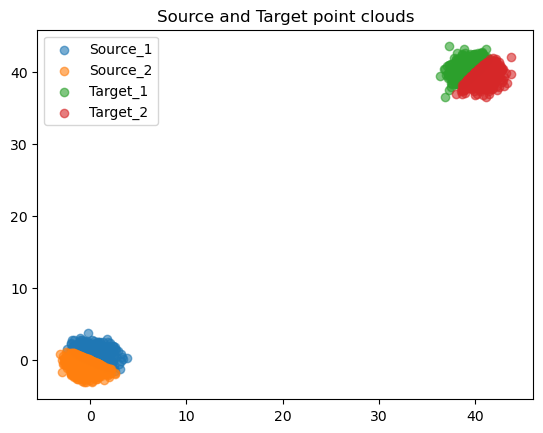

In [112]:
import matplotlib.pyplot as plt

# Supposons que partition_x et partition_y soient des array de labels (0 ou 1)
# Vous vouliez extraire la partition « 1 » pour x, et la partition « 1 » pour y :

mask_x = (partition_x == 1)     # True pour les points de x dans le bloc 1
mask_y = (partition_y == 1)     # True pour les points de y dans le bloc 1

# Utiliser ~mask pour l’inverse du masque :
x1 = x[mask_x]     # éléments de x où partition_x == 1 :contentReference[oaicite:0]{index=0}
x2 = x[~mask_x]    # tous les autres :contentReference[oaicite:1]{index=1}

y1 = y[mask_y]     # éléments de y où partition_y == 1 :contentReference[oaicite:2]{index=2}
y2 = y[~mask_y]    # tous les autres :contentReference[oaicite:3]{index=3}

# Affichage
plt.scatter(x1[:, 0], x1[:, 1], label="Source_1", alpha=0.6)
plt.scatter(x2[:, 0], x2[:, 1], label="Source_2", alpha=0.6)

plt.scatter(y1[:, 0], y1[:, 1], label="Target_1", alpha=0.6)
plt.scatter(y2[:, 0], y2[:, 1], label="Target_2", alpha=0.6)

plt.legend()
plt.title("Source and Target point clouds")
plt.show()


# Nouvelle essai avec compilation JIT

In [49]:
import jax
from jax import tree_util

@tree_util.register_pytree_node_class
class LRSinkhornFixedG(LRSinkhorn):
    def dykstra_update_lse(self, *args, **kw):
        q, r, _ = super().dykstra_update_lse(*args, **kw)
        g = jnp.array([0.5,0.5], q.dtype)
        return q, r, g
    def dykstra_update_kernel(self, *args, **kw):
        q, r, _ = super().dykstra_update_kernel(*args, **kw)
        g = jnp.array([0.5,0.5], q.dtype)
        return q, r, g

    # tree_flatten/tree_unflatten hérités de la classe si définis,
    # sinon il vous faudra les fournir manuellement via register_pytree_node.


In [50]:
import jax
import jax.numpy as jnp
from ott.geometry import pointcloud
from ott.problems.linear import linear_problem
from ott.initializers.linear.initializers_lr import KMeansInitializer
from ott.solvers.linear.sinkhorn_lr import LRSinkhorn

# 1) Définissez l’initialiseur
init = KMeansInitializer(rank=2,
                         min_iterations=50,
                         max_iterations=200)

# 2) Créez la sous‑classe qui force g = [0.5, 0.5]
class LRSinkhornFixedG(LRSinkhorn):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        assert self.rank == 2, "Cette classe ne gère que rank=2"
    def dykstra_update_lse(self, *args, **kwargs):
        q, r, _ = super().dykstra_update_lse(*args, **kwargs)
        g = jnp.array([0.5, 0.5], dtype=q.dtype)
        return q, r, g
    def dykstra_update_kernel(self, *args, **kwargs):
        q, r, _ = super().dykstra_update_kernel(*args, **kwargs)
        g = jnp.array([0.5, 0.5], dtype=q.dtype)
        return q, r, g

# 3) Préparez le problème OT
def low_rank_ot_fixed_g(x_block, y_block):
    geom    = pointcloud.PointCloud(x_block, y_block)
    n       = x_block.shape[0]
    a       = jnp.ones(n) / n
    ot_prob = linear_problem.LinearProblem(geom, a, a)

    # 4) Instanciez et capturez solver dans une closure
    solver = LRSinkhornFixedG(rank=2, initializer=init)

    def run(p):
        return solver(p)

    # 5) JIT la closure (solver n’est pas un argument tracé)
    run_jit = jax.jit(run)

    out = run_jit(ot_prob)
    return out.q, out.r, out.g

# 6) Appel  
Q, R, g = low_rank_ot_fixed_g(x, y)
print("g =", g)  # => [0.5 0.5]


TypeError: Argument '<__main__.LRSinkhornFixedG object at 0x7f86c47bd760>' of type '<class '__main__.LRSinkhornFixedG'>' is not a valid JAX type

In [45]:
# Exemple d’appel
Q, R, g = low_rank_ot_fixed_g(x, y)
print("g =", g)  # => [0.5 0.5]

TypeError: Argument '<__main__.LRSinkhornFixedG object at 0x7f870c4df6b0>' of type '<class '__main__.LRSinkhornFixedG'>' is not a valid JAX type